# Stage 6 — Enhanced evaluation & visualisation

The Stage 4 demo proved a metric table can rank models, but a metric
table alone does not show *how* one model loses to another.  Stage 6
adds the diagnostic library
([`bristol_ml.evaluation.plots`](../src/bristol_ml/evaluation/plots.py))
that this notebook drives — five colourblind-safe figures (Okabe-Ito
qualitative palette; `cividis` sequential; `RdBu_r` diverging) plus the
holdout-window benchmark bar chart, applied side-by-side to **both**
OLS variants:

- **Linear OLS — weather only** (Stage 4 / `features=weather_only`).
- **Linear OLS — weather + calendar** (Stage 5 /
  `features=weather_calendar`).

Reading the figures together is the demo moment: the calendar OLS
shrinks the morning-peak residual cluster, sharpens the q10-q90
uncertainty band on weekday afternoons, and narrows the gap to the
NESO day-ahead forecast on the holdout-window benchmark bar.  The
weekly ACF spike at lag-168 survives in *both* — that's the lead-in
for Stage 7's SARIMAX dual-seasonality treatment.

This notebook is a thin renderer — the substantive computation
(rolling-origin folds, residuals, per-fold errors, NESO comparison)
all delegates to `bristol_ml.evaluation.{harness,benchmarks,plots}`.
The plumbing for both feature sets lives behind a single Hydra group
swap (`features=weather_calendar`); see Stage 5's retrospective for
how the swap works.


In [1]:
# T6 Cell 1 — Bootstrap, locate the repo root, load both feature configs.
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
for _path in (REPO_ROOT, REPO_ROOT / "src"):
    sp = str(_path)
    if sp not in sys.path:
        sys.path.insert(0, sp)
os.chdir(REPO_ROOT)  # so cache_dir interpolations (data/...) resolve

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402

from bristol_ml import load_config  # noqa: E402

# Both feature sets come from the same default config tree; only the
# `features=` group swaps.  Narrow the rolling-origin window so this
# notebook completes in well under a minute on a warm cache; the
# train CLI keeps the wider production defaults.
_HYDRA_OVERRIDES = [
    "evaluation.rolling_origin.min_train_periods=720",
    "evaluation.rolling_origin.test_len=168",
    "evaluation.rolling_origin.step=168",
]
cfg_wonly = load_config(overrides=list(_HYDRA_OVERRIDES))
cfg_wcal = load_config(overrides=["features=weather_calendar", *_HYDRA_OVERRIDES])

assert cfg_wonly.features.weather_only is not None
assert cfg_wcal.features.weather_calendar is not None
print("Stage 6 — enhanced evaluation")
print(
    f"  rolling_origin: min_train={cfg_wonly.evaluation.rolling_origin.min_train_periods}, "
    f"test_len={cfg_wonly.evaluation.rolling_origin.test_len}, "
    f"step={cfg_wonly.evaluation.rolling_origin.step}"
)
print(f"  feature sets:   weather_only -> {cfg_wonly.features.weather_only.cache_filename}")
print(f"                  weather_calendar -> {cfg_wcal.features.weather_calendar.cache_filename}")

Stage 6 — enhanced evaluation
  rolling_origin: min_train=720, test_len=168, step=168
  feature sets:   weather_only -> weather_only.parquet
                  weather_calendar -> weather_calendar.parquet


In [2]:
# T6 Cell 2 — Load both warm feature-table parquets.
#
# Both caches are pre-populated by running the assembler CLI once per
# feature set; the README's "Regenerating feature caches after a code
# change" section names the exact commands.  When a cache is missing
# the notebook prints an actionable banner and skips that side of the
# comparison rather than crashing — so a half-warm clone still
# executes top-to-bottom.
from bristol_ml.features import assembler


def _load_or_warn(cache_path, loader, *, regen_cmd):
    """Return the loaded frame or None with a documented banner."""
    if cache_path.exists():
        df = loader(cache_path).set_index("timestamp_utc")
        return df
    print(
        f"WARNING: feature-table cache missing at {cache_path}.\n"
        f"  Regenerate with: {regen_cmd}\n"
        f"  This notebook will skip the comparison side that needs it."
    )
    return None


wonly_path = (
    cfg_wonly.features.weather_only.cache_dir / cfg_wonly.features.weather_only.cache_filename
)
wcal_path = (
    cfg_wcal.features.weather_calendar.cache_dir / cfg_wcal.features.weather_calendar.cache_filename
)

_BASE_REGEN = "uv run python -m bristol_ml.features.assembler"
features_wonly = _load_or_warn(
    wonly_path,
    assembler.load,
    regen_cmd=f"{_BASE_REGEN} features=weather_only --cache offline",
)
features_wcal = _load_or_warn(
    wcal_path,
    assembler.load_calendar,
    regen_cmd=f"{_BASE_REGEN} features=weather_calendar --cache offline",
)

if features_wonly is not None:
    print(f"weather_only:     rows={len(features_wonly):,}  cols={features_wonly.shape[1]}")
if features_wcal is not None:
    print(f"weather_calendar: rows={len(features_wcal):,}  cols={features_wcal.shape[1]}")

weather_only:     rows=70,128  cols=9
weather_calendar: rows=70,128  cols=55


In [3]:
# T6 Cell 3 — Fit both OLS models on the full window AND run rolling-
# origin evaluation against each.  ``return_predictions=True`` emits
# the long-form per-fold-errors frame that ``forecast_overlay_with_band``
# consumes (Stage 6 D9 single-flag concession).
from bristol_ml.evaluation.harness import evaluate
from bristol_ml.evaluation.metrics import METRIC_REGISTRY
from bristol_ml.features.calendar import CALENDAR_VARIABLE_COLUMNS
from bristol_ml.models.linear import LinearModel
from bristol_ml.models.naive import NaiveModel
from conf._schemas import LinearConfig, NaiveConfig

WEATHER_COLS = tuple(name for name, _ in assembler.WEATHER_VARIABLE_COLUMNS)
CALENDAR_COLS = tuple(name for name, _ in CALENDAR_VARIABLE_COLUMNS)
WEATHER_CALENDAR_COLS = WEATHER_COLS + CALENDAR_COLS

split_cfg = cfg_wonly.evaluation.rolling_origin  # identical across both configs
metric_fns = [METRIC_REGISTRY[name] for name in ("mae", "mape", "rmse", "wape")]

results = {}  # name -> {"per_fold_errors": ..., "linear": ..., "metrics_df": ...}

if features_wonly is not None:
    linear_wonly = LinearModel(LinearConfig(feature_columns=WEATHER_COLS))
    linear_wonly.fit(features_wonly, features_wonly["nd_mw"])
    metrics_wonly, errors_wonly = evaluate(
        LinearModel(LinearConfig(feature_columns=WEATHER_COLS)),
        features_wonly,
        split_cfg,
        metric_fns,
        feature_columns=WEATHER_COLS,
        return_predictions=True,
    )
    results["weather_only"] = {
        "linear": linear_wonly,
        "metrics_df": metrics_wonly,
        "per_fold_errors": errors_wonly,
        "features": features_wonly,
    }
    print(f"weather_only      rolling-origin folds: {len(metrics_wonly)}")

if features_wcal is not None:
    linear_wcal = LinearModel(LinearConfig(feature_columns=WEATHER_CALENDAR_COLS))
    linear_wcal.fit(features_wcal, features_wcal["nd_mw"])
    metrics_wcal, errors_wcal = evaluate(
        LinearModel(LinearConfig(feature_columns=WEATHER_CALENDAR_COLS)),
        features_wcal,
        split_cfg,
        metric_fns,
        feature_columns=WEATHER_CALENDAR_COLS,
        return_predictions=True,
    )
    results["weather_calendar"] = {
        "linear": linear_wcal,
        "metrics_df": metrics_wcal,
        "per_fold_errors": errors_wcal,
        "features": features_wcal,
    }
    print(f"weather_calendar  rolling-origin folds: {len(metrics_wcal)}")

# Side-by-side cross-fold means
if results:
    summary = pd.DataFrame(
        {
            name: r["metrics_df"][["mae", "mape", "rmse", "wape"]].mean()
            for name, r in results.items()
        }
    ).T
    summary.index.name = "feature_set"
    print()
    print("Cross-fold mean metrics (lower is better):")
    print(summary.to_string(float_format=lambda v: f"{v:.2f}"))

2026-05-04 15:03:03.318 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 0 train_len=720 test_len=168 metrics={'mae': 5214.409630030415, 'mape': 0.15189624960960327, 'rmse': 6028.7565913520975, 'wape': 0.1439636487023875}


2026-05-04 15:03:03.322 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 1 train_len=888 test_len=168 metrics={'mae': 5583.913299480735, 'mape': 0.16277823508938213, 'rmse': 6217.691882642902, 'wape': 0.15600625462112436}


2026-05-04 15:03:03.326 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 2 train_len=1056 test_len=168 metrics={'mae': 6321.314869996118, 'mape': 0.19079380086154132, 'rmse': 7251.780129619989, 'wape': 0.18143269454766972}


2026-05-04 15:03:03.330 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 3 train_len=1224 test_len=168 metrics={'mae': 5260.2351745742535, 'mape': 0.15592489603180232, 'rmse': 6263.550548431326, 'wape': 0.1453174845334888}


2026-05-04 15:03:03.334 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 4 train_len=1392 test_len=168 metrics={'mae': 5598.089710663313, 'mape': 0.14119856704333372, 'rmse': 6884.236781598009, 'wape': 0.14665439213425896}


...

2026-05-04 15:03:46.278 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 410 train_len=69600 test_len=168 metrics={'mae': 1571.7479697119047, 'mape': 0.05610169384004341, 'rmse': 2179.774769056688, 'wape': 0.052192067886421514}


2026-05-04 15:03:46.414 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 411 train_len=69768 test_len=168 metrics={'mae': 1667.5161976655693, 'mape': 0.05839869186059977, 'rmse': 2119.2633144302376, 'wape': 0.05471942575589397}


2026-05-04 15:03:46.572 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 412 train_len=69936 test_len=168 metrics={'mae': 2565.713452191243, 'mape': 0.09340337725464713, 'rmse': 3085.1442553021234, 'wape': 0.0904077937248801}


2026-05-04 15:03:46.575 | INFO     | bristol_ml.evaluation.harness:evaluate:287 - Evaluator complete: total_folds=413 elapsed_seconds=39.343 summary={'mae': {'mean': 2023.4967725362546, 'std': 718.7556717918903}, 'mape': {'mean': 0.0796995808491089, 'std': 0.032742725763726534}, 'rmse': {'mean': 2421.5058271529156, 'std': 770.8597942274795}, 'wape': {'mean': 0.07648921282772805, 'std': 0.032711887701744526}}


weather_calendar  rolling-origin folds: 413

Cross-fold mean metrics (lower is better):
                     mae  mape    rmse  wape
feature_set                                 
weather_only     4944.78  0.20 5771.73  0.18
weather_calendar 2023.50  0.08 2421.51  0.08


2026-05-04 15:03:47.474 | INFO     | bristol_ml.evaluation.plots:predicted_vs_actual:421 - predicted_vs_actual: down-sampled 70128 -> 20000 rows (cap=20000, seed=42)


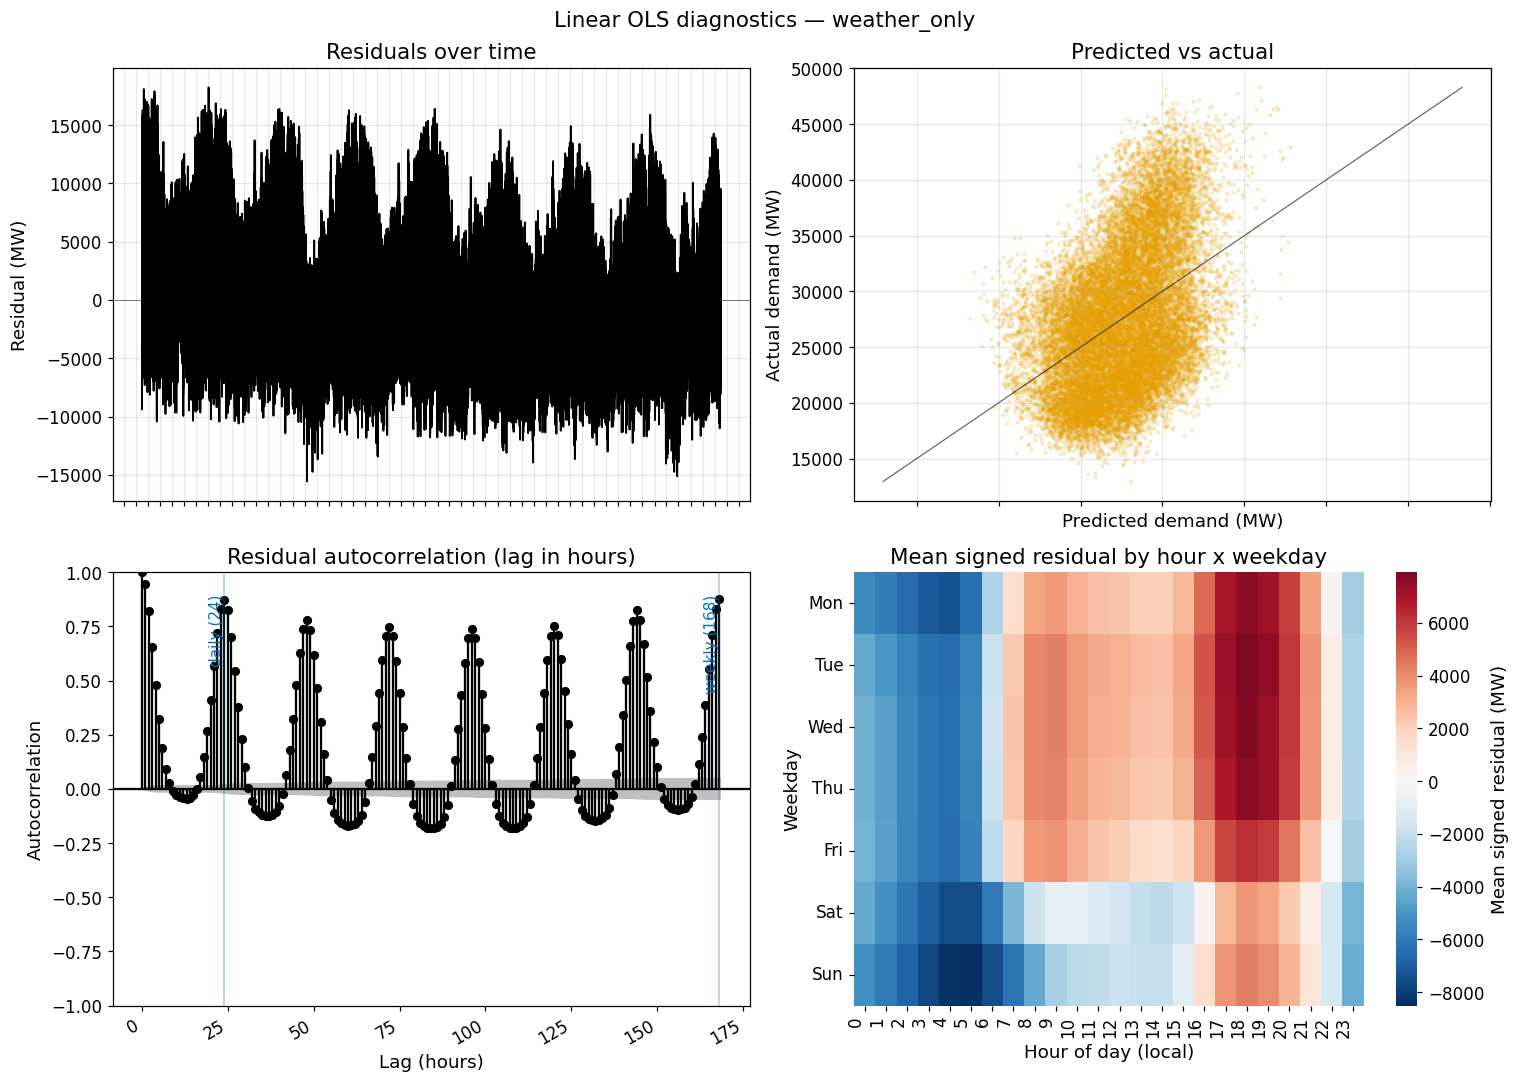

2026-05-04 15:03:49.813 | INFO     | bristol_ml.evaluation.plots:predicted_vs_actual:421 - predicted_vs_actual: down-sampled 70128 -> 20000 rows (cap=20000, seed=42)


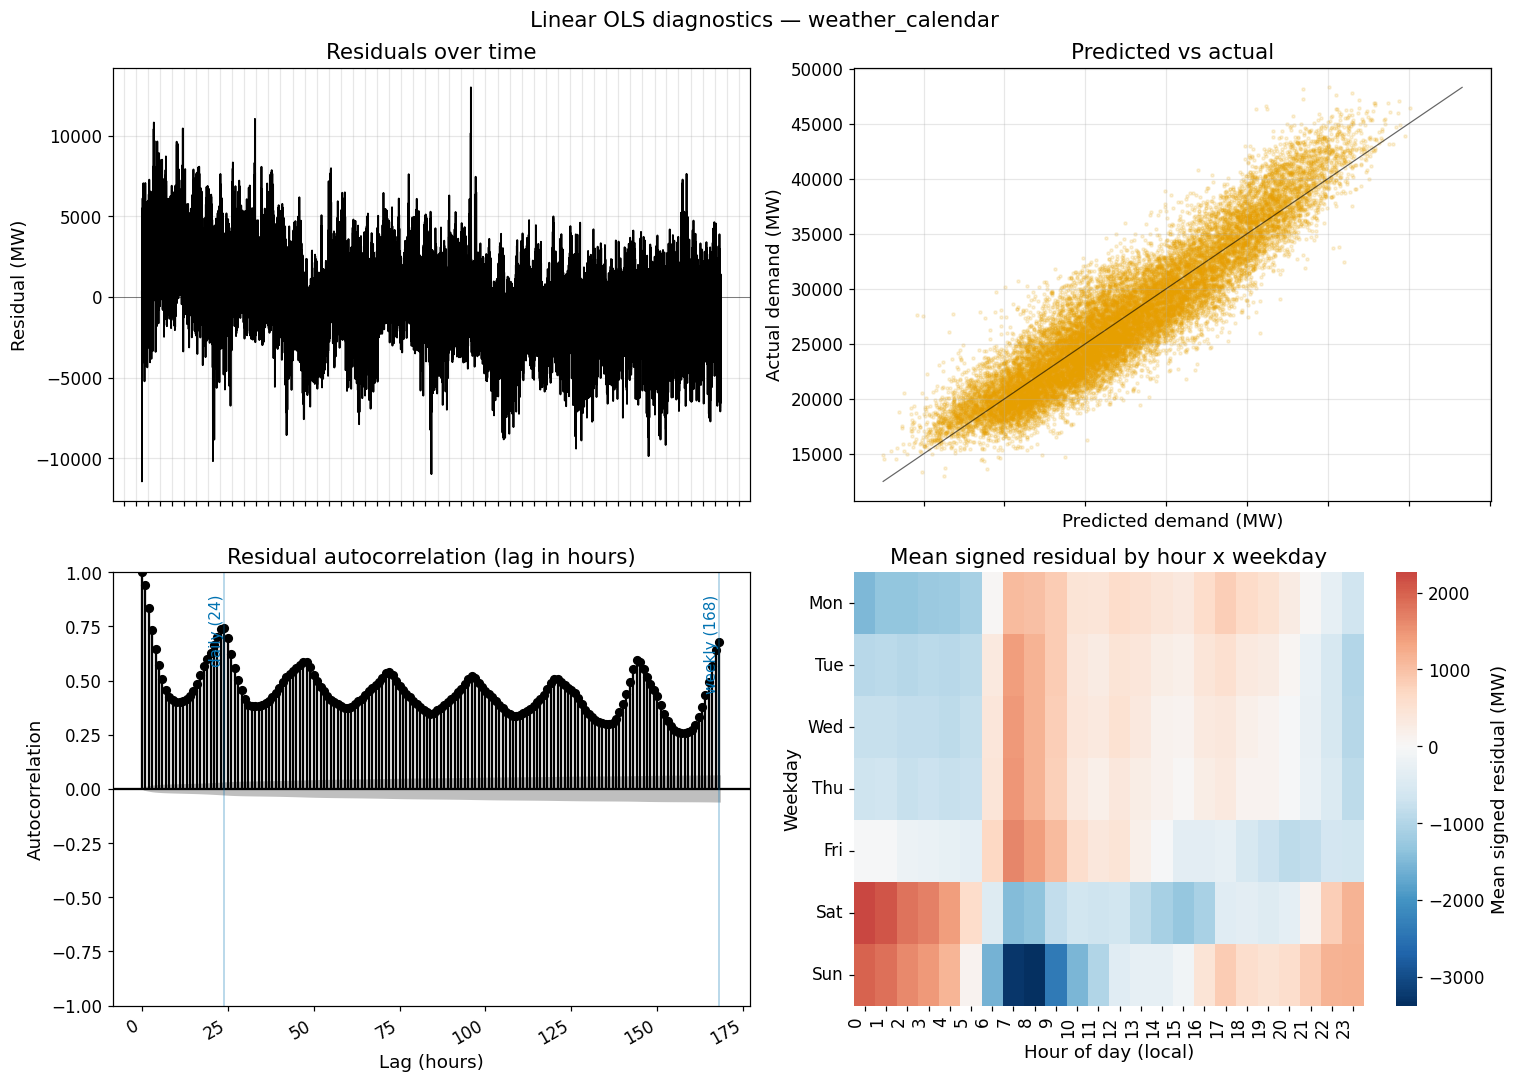

In [4]:
# T6 Cell 4 — 2x2 diagnostic grid for each linear OLS model.
#
# Top-left:    residuals_vs_time          — visible serial structure
#              that the linear fit failed to capture.
# Top-right:   predicted_vs_actual         — calibration (45-degree
#              reference) and tail behaviour.
# Bottom-left: acf_residuals (lags=168)    — the 24h / 168h reference
#              spikes; daily residual periodicity is the lead-in for
#              SARIMAX in Stage 7.
# Bottom-right: error_heatmap_hour_weekday — when the model is biased,
#               by hour of day and day of week.
from bristol_ml.evaluation import plots


def _diagnostic_grid(label, bundle):
    feats = bundle["features"]
    linear = bundle["linear"]
    fitted = linear.results.fittedvalues
    residuals = (feats["nd_mw"] - fitted).rename("residual_mw")
    predictions = linear.predict(feats)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plots.residuals_vs_time(residuals, ax=axes[0, 0])
    plots.predicted_vs_actual(feats["nd_mw"], predictions, ax=axes[0, 1])
    plots.acf_residuals(residuals, lags=168, ax=axes[1, 0])
    plots.error_heatmap_hour_weekday(residuals, ax=axes[1, 1])
    fig.suptitle(f"Linear OLS diagnostics — {label}", fontsize=14)
    plt.tight_layout()
    plt.show()


for name in ("weather_only", "weather_calendar"):
    if name in results:
        _diagnostic_grid(name, results[name])

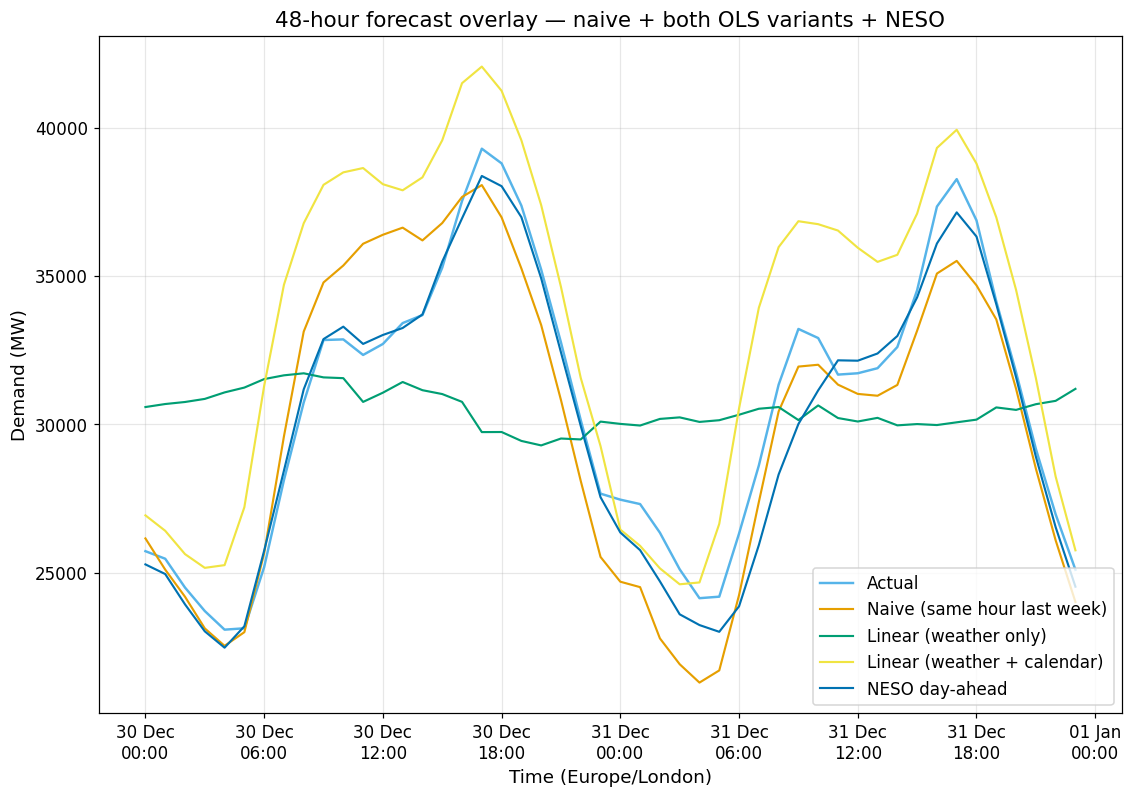

In [5]:
# T6 Cell 5 — 48-hour forecast overlay: actual + naive + both OLS
# variants + (optionally) NESO day-ahead.  Picks the last 48 hourly
# rows of the smaller of the two feature tables so both forecasts can
# be plotted on a shared axis.

from bristol_ml.ingestion import neso_forecast as neso_forecast_mod


# Pick a 48-hour window common to both feature sets.  Use the calendar
# frame's last 48 rows when present (richer feature set is the
# canonical demo); fall back to the weather-only frame.
def _pick_window(bundle, hours=48):
    return bundle["features"].iloc[-hours:].copy()


canonical = results.get("weather_calendar") or results.get("weather_only")
window = _pick_window(canonical) if canonical is not None else None
naive = NaiveModel(NaiveConfig(strategy="same_hour_last_week"))
if canonical is not None:
    naive.fit(canonical["features"], canonical["features"]["nd_mw"])

predictions_by_name = {}
if window is not None:
    predictions_by_name["Naive (same hour last week)"] = naive.predict(window)
    if "weather_only" in results:
        # The full-window-fit linear is what produces the headline 48h
        # overlay; ``predict`` slices by feature name so the calendar
        # columns are simply ignored when a weather-only model sees a
        # calendar frame.
        wonly_for_window = results["weather_only"]["linear"].predict(
            window[[*WEATHER_COLS, "nd_mw"]]
            if set(WEATHER_COLS).issubset(window.columns)
            else window
        )
        predictions_by_name["Linear (weather only)"] = wonly_for_window
    if "weather_calendar" in results:
        wcal_for_window = results["weather_calendar"]["linear"].predict(window)
        predictions_by_name["Linear (weather + calendar)"] = wcal_for_window

# NESO three-way: only when the forecast cache is warm.
neso_df_local = None
if cfg_wonly.ingestion.neso_forecast is not None:
    forecast_cache = (
        cfg_wonly.ingestion.neso_forecast.cache_dir
        / cfg_wonly.ingestion.neso_forecast.cache_filename
    )
    if forecast_cache.exists():
        neso_df_local = neso_forecast_mod.load(forecast_cache)
        from bristol_ml.evaluation.benchmarks import align_half_hourly_to_hourly

        aligned = align_half_hourly_to_hourly(neso_df_local, aggregation="mean")
        if window is not None:
            window_start, window_end = window.index[0], window.index[-1]
            neso_slice = aligned.loc[window_start:window_end]
            if not neso_slice.empty:
                predictions_by_name["NESO day-ahead"] = neso_slice["demand_forecast_mw"]

if window is not None and predictions_by_name:
    fig = plots.forecast_overlay(
        actual=window["nd_mw"],
        predictions_by_name=predictions_by_name,
        title="48-hour forecast overlay — naive + both OLS variants + NESO",
    )
    plt.show()
else:
    print("No feature-table cache warm — skipping 48-hour overlay.")

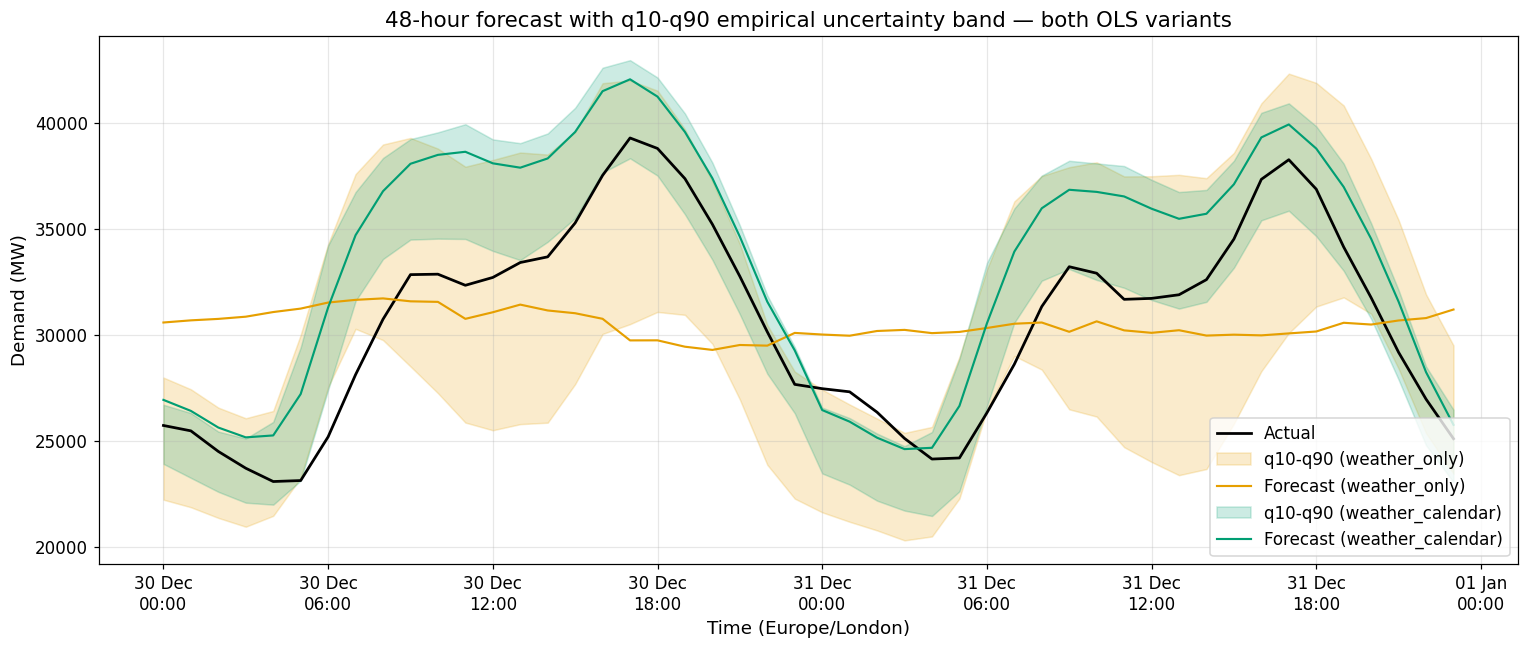

In [6]:
# T6 Cell 6 — q10-q90 empirical uncertainty band, both OLS variants
# overlaid on a single 48-hour axis so the calendar uplift on the band
# width is visible by eye comparison.  The band is non-parametric:
# per-horizon quantiles of the rolling-origin per-fold errors
# (Stage 6 D8).  After the 2026-05-04 sign-inversion fix the band
# tracks where actual is likely to land — when the band is narrow the
# model is confident at that hour-of-day; when wide it is hedging.
#
# Both variants are drawn in distinct Okabe-Ito colours; the actual
# series renders once (black) so it is unambiguous which line is the
# observation versus the forecast.
present = [name for name in ("weather_only", "weather_calendar") if name in results]
if window is not None and present:
    # Choose a single 48-hour window — the calendar frame is the canonical
    # demo grid, so use it whenever present.  Both linear models can
    # ``predict`` on it because LinearModel.predict slices its input by
    # the model's own ``feature_columns`` field.
    canonical_for_band = results.get("weather_calendar") or results.get("weather_only")
    band_window = _pick_window(canonical_for_band)

    def _band_edges(per_fold_errors, point_prediction, *, quantiles=(0.1, 0.9)):
        """Mirror plots.forecast_overlay_with_band's band math (sign-corrected).
        Returns (lower, upper) numpy arrays aligned to ``point_prediction``.
        """
        q_lo_val, q_hi_val = quantiles
        band = (
            per_fold_errors.groupby("horizon_h")["error"].quantile([q_lo_val, q_hi_val]).unstack()
        )
        n = min(len(point_prediction), band.shape[0])
        q_lo = band[q_lo_val].iloc[:n].to_numpy(dtype=np.float64)
        q_hi = band[q_hi_val].iloc[:n].to_numpy(dtype=np.float64)
        point_arr = np.asarray(point_prediction.values, dtype=np.float64)[:n]
        return point_arr + q_lo, point_arr + q_hi

    fig, ax = plt.subplots(figsize=(14, 6))
    local_idx = band_window.index.tz_convert("Europe/London")
    actual_arr = band_window["nd_mw"].to_numpy(dtype=np.float64)
    ax.plot(local_idx, actual_arr, linewidth=1.8, color=plots.OKABE_ITO[0], label="Actual")

    band_colours = {"weather_only": plots.OKABE_ITO[1], "weather_calendar": plots.OKABE_ITO[3]}
    for name in present:
        bundle = results[name]
        point = bundle["linear"].predict(band_window)
        lower, upper = _band_edges(bundle["per_fold_errors"], point)
        n = len(lower)
        colour = band_colours[name]
        ax.fill_between(
            local_idx[:n],
            lower,
            upper,
            alpha=0.20,
            color=colour,
            label=f"q10-q90 ({name})",
        )
        ax.plot(
            local_idx[:n],
            point.to_numpy(dtype=np.float64)[:n],
            linewidth=1.4,
            color=colour,
            label=f"Forecast ({name})",
        )

    import matplotlib.dates as _mdates  # local alias to avoid shadowing

    ax.xaxis.set_major_formatter(_mdates.DateFormatter("%d %b\n%H:%M"))
    ax.set_xlabel("Time (Europe/London)")
    ax.set_ylabel("Demand (MW)")
    ax.set_title("48-hour forecast with q10-q90 empirical uncertainty band — both OLS variants")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("No feature-table cache warm — skipping uncertainty band.")

## Holdout-window benchmark — what is "holdout"?

The **holdout window** is a fixed future interval reserved by
`NesoBenchmarkConfig.holdout_start` / `holdout_end` (set in
`conf/evaluation/benchmark.yaml`) that **no model is allowed to fit
on**.  It defines a single shared yardstick for cross-model
comparison: every candidate fits on the data preceding the holdout,
predicts inside the holdout, and is scored on the same evaluation
target.  The NESO day-ahead forecast is also clipped to this window
so the three-way comparison (naive / OLS / NESO) is on the same
hourly grid.

The next cell rolls **weekly folds within the holdout** — for each
fold, the training set is the data preceding the fold's test week
(sliding window, fixed width) and the test set is the next 168
hourly rows.  The default fold length matches the seasonal-naive
lookback so `same_hour_last_week` works without splitter twiddling
(see the 2026-05-04 `benchmark_holdout_bar` fold-length fix).
Per-fold metrics are averaged across folds; the bars below are those
cross-fold means.

Two side-by-side panels split the metrics by **scale** so they stay
visually comparable:

- **Left panel — MW-scale metrics** (MAE, RMSE) in megawatts.
- **Right panel — fraction-scale metrics** (MAPE, WAPE) as decimal
  fractions, e.g. `0.05` = 5 %.

A combined single-panel chart would render the fraction metrics as
flat zero bars next to four-digit MW bars — informationless.  The
unit-split layout is the project's convention (`_METRIC_UNIT_LABEL`
in `bristol_ml.evaluation.plots`).

All four candidates appear in **both** panels: naive
(`same_hour_last_week`), linear OLS on weather only, linear OLS on
weather + calendar, and the NESO day-ahead.  The calendar uplift is
the gap between the two linear bars; the residual gap between the
calendar OLS and NESO is what Stages 7+ chip away at.


2026-05-04 15:03:51.741 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 0 train_len=50376 test_len=168 metrics={'mae': 4140.156943828614, 'mape': 0.19555114669360713, 'rmse': 4988.886695172126, 'wape': 0.17290415025903}


2026-05-04 15:03:51.750 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 1 train_len=50376 test_len=168 metrics={'mae': 4694.003404777499, 'mape': 0.2194169497671003, 'rmse': 5445.57684833802, 'wape': 0.19292383448970962}


2026-05-04 15:03:51.762 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 2 train_len=50376 test_len=168 metrics={'mae': 4635.586050027175, 'mape': 0.2029268877858004, 'rmse': 5572.236538172616, 'wape': 0.17789736682788557}


2026-05-04 15:03:51.772 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 3 train_len=50376 test_len=168 metrics={'mae': 4687.498799385854, 'mape': 0.18839354101706962, 'rmse': 5372.275063549792, 'wape': 0.1733184961577917}


2026-05-04 15:03:51.782 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 4 train_len=50376 test_len=168 metrics={'mae': 4917.245079827394, 'mape': 0.19329338192914877, 'rmse': 5636.42415825119, 'wape': 0.1770499855356894}


...

2026-05-04 15:04:08.174 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 115 train_len=50376 test_len=168 metrics={'mae': 1299.7482969486086, 'mape': 0.04628438335272767, 'rmse': 1754.858276535784, 'wape': 0.042481086786244945}


2026-05-04 15:04:08.300 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 116 train_len=50376 test_len=168 metrics={'mae': 1960.313307291197, 'mape': 0.0730922775341344, 'rmse': 2386.3081314548817, 'wape': 0.06895477714716336}


2026-05-04 15:04:08.302 | INFO     | bristol_ml.evaluation.harness:evaluate:287 - Evaluator complete: total_folds=117 elapsed_seconds=14.840 summary={'mae': {'mean': 1819.9357634386838, 'std': 491.3256913712972}, 'mape': {'mean': 0.07416787683629755, 'std': 0.023555089963561107}, 'rmse': {'mean': 2227.3243408478706, 'std': 545.2659887079352}, 'wape': {'mean': 0.07097597788089982, 'std': 0.023293377379454267}}


2026-05-04 15:04:08.304 | INFO     | bristol_ml.evaluation.benchmarks:compare_on_holdout:304 - Benchmark comparison: models=['linear_weather_calendar'] neso_rows=19656 holdout=[2023-10-01 00:00:00+00:00, 2025-12-27 23:00:00+00:00]


Cross-fold mean metrics across the holdout window:
                             mae  mape     rmse  wape
model                                                
naive                   2139.834 0.082 2643.428 0.080
linear_weather_only     4699.906 0.190 5482.775 0.178
linear_weather_calendar 1819.936 0.074 2227.324 0.071
neso                     632.407 0.025  844.872 0.024



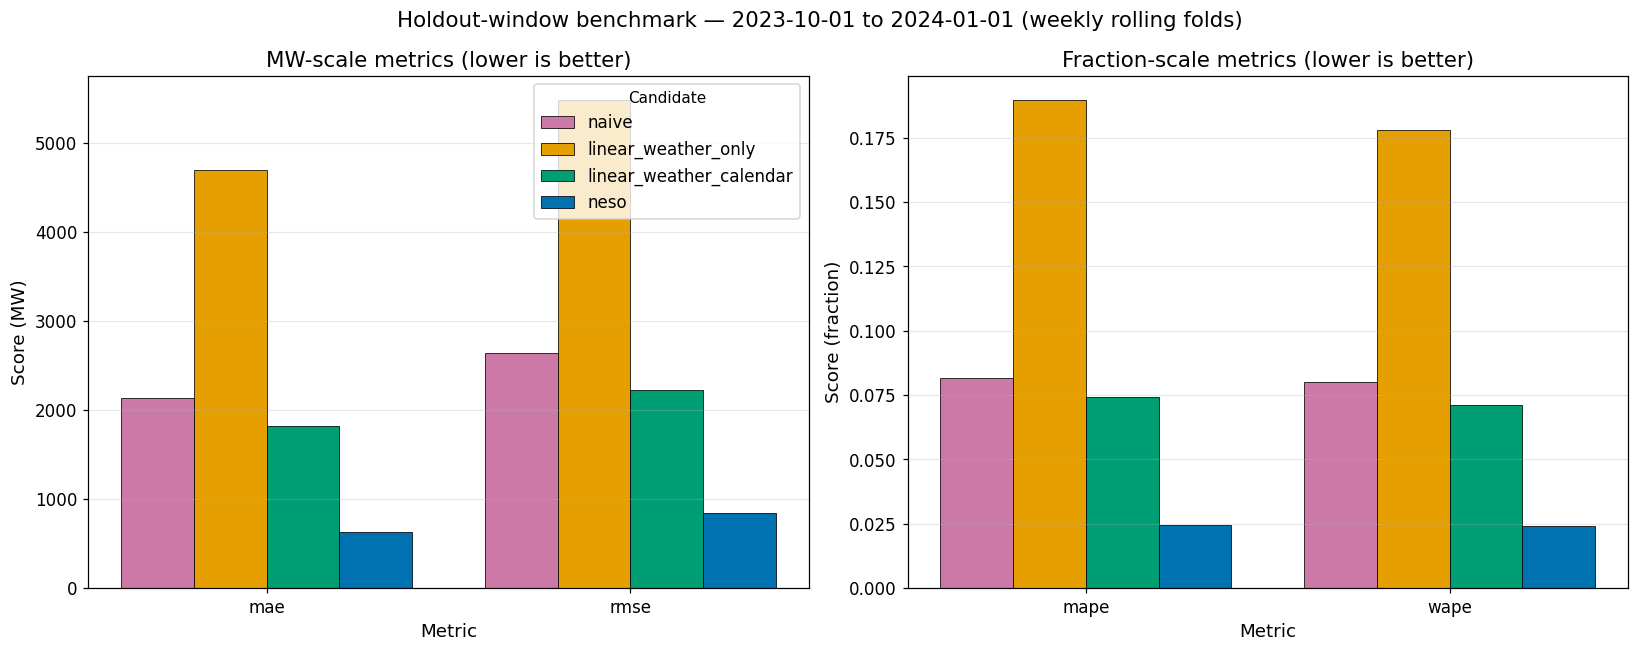

In [7]:
# T6 Cell 7 — Combined holdout benchmark, all four candidates on
# one chart, split into two panels by metric scale.
#
# Why we don't call ``plots.benchmark_holdout_bar`` directly here:
# that helper feeds ``compare_on_holdout``, which slices the feature
# frame once with a single shared ``feature_columns`` argument.  Our
# two linear models need DIFFERENT feature columns (weather only vs
# weather + calendar), so the helper cannot evaluate them in one call
# without one of the models silently dropping its calendar columns.
# We instead score each feature set's candidates separately, merge
# the resulting metric tables, and render a single combined chart.
benchmark_ready = (
    cfg_wonly.evaluation.benchmark is not None
    and neso_df_local is not None
    and "weather_only" in results
    and "weather_calendar" in results
)
if benchmark_ready:
    from bristol_ml.evaluation.benchmarks import compare_on_holdout
    from conf._schemas import SplitterConfig

    holdout_start = cfg_wonly.evaluation.benchmark.holdout_start
    holdout_end = cfg_wonly.evaluation.benchmark.holdout_end

    # Build the rolling-weekly splitter once and reuse for both feature
    # sets so every candidate is scored on the same fold sequence
    # (same train-set widths, same test-week boundaries).  Both feature
    # frames share an hourly DatetimeIndex aligned by timestamp_utc, so
    # the same min_train / test_len arithmetic applies.
    df_wonly_idx = results["weather_only"]["features"]
    train_mask = df_wonly_idx.index < pd.Timestamp(holdout_start)
    test_mask = (df_wonly_idx.index >= pd.Timestamp(holdout_start)) & (
        df_wonly_idx.index <= pd.Timestamp(holdout_end)
    )
    min_train = int(train_mask.sum())
    test_len = min(168, int(test_mask.sum()))  # weekly folds
    splitter_cfg = SplitterConfig(
        min_train_periods=min_train,
        test_len=test_len,
        step=test_len,
        gap=0,
        fixed_window=True,
    )

    # ``compare_on_holdout`` takes ``feature_columns`` and forwards it
    # to the harness, which slices the feature frame BEFORE handing it
    # to model.fit().  Each call must explicitly name the columns the
    # candidate models actually need — defaulting to None falls back to
    # the assembler's weather columns and silently strips the calendar
    # half from the second call.
    table_wonly = compare_on_holdout(
        {
            "naive": NaiveModel(NaiveConfig(strategy="same_hour_last_week")),
            "linear_weather_only": LinearModel(LinearConfig(feature_columns=WEATHER_COLS)),
        },
        df_wonly_idx,
        neso_df_local,
        splitter_cfg,
        metric_fns,
        feature_columns=WEATHER_COLS,
    )
    table_wcal = compare_on_holdout(
        {
            "linear_weather_calendar": LinearModel(
                LinearConfig(feature_columns=WEATHER_CALENDAR_COLS)
            ),
        },
        results["weather_calendar"]["features"],
        neso_df_local,
        splitter_cfg,
        metric_fns,
        feature_columns=WEATHER_CALENDAR_COLS,
    )

    # Merge: keep ``naive`` and ``neso`` from the weather-only call (NESO
    # row is identical across the two calls because it is scored on the
    # same hourly grid); add the calendar-OLS row from the second call.
    combined = pd.concat(
        [
            table_wonly.loc[["naive", "linear_weather_only", "neso"]],
            table_wcal.loc[["linear_weather_calendar"]],
        ]
    )
    # Re-order so the storyline reads naive -> wonly -> wcal -> neso.
    combined = combined.reindex(["naive", "linear_weather_only", "linear_weather_calendar", "neso"])

    print("Cross-fold mean metrics across the holdout window:")
    print(combined.to_string(float_format=lambda v: f"{v:.3f}"))
    print()

    # Two panels by metric scale.  Names map to ``_METRIC_UNIT_LABEL`` in
    # plots.py — MAE / RMSE in MW; MAPE / WAPE as fractions.
    mw_metrics = ("mae", "rmse")
    frac_metrics = ("mape", "wape")
    fig, (ax_mw, ax_frac) = plt.subplots(1, 2, figsize=(15, 6))
    candidate_colours = {
        "naive": plots.OKABE_ITO[7],  # reddish purple
        "linear_weather_only": plots.OKABE_ITO[1],  # orange
        "linear_weather_calendar": plots.OKABE_ITO[3],  # bluish green
        "neso": plots.OKABE_ITO[5],  # blue
    }
    for ax, metrics_subset, ylabel in (
        (ax_mw, mw_metrics, "Score (MW)"),
        (ax_frac, frac_metrics, "Score (fraction)"),
    ):
        n_groups = len(metrics_subset)
        n_cands = len(combined.index)
        bar_width = 0.8 / max(n_cands, 1)
        x_positions = np.arange(n_groups, dtype=np.float64)
        for offset, candidate in enumerate(combined.index):
            values = combined.loc[candidate, list(metrics_subset)].to_numpy(dtype=np.float64)
            ax.bar(
                x_positions + offset * bar_width,
                values,
                width=bar_width,
                color=candidate_colours[candidate],
                label=candidate,
                edgecolor="black",
                linewidth=0.5,
            )
        ax.set_xticks(x_positions + bar_width * (n_cands - 1) / 2.0)
        ax.set_xticklabels(list(metrics_subset))
        ax.set_xlabel("Metric")
        ax.set_ylabel(ylabel)
        ax.grid(True, axis="y", alpha=0.3)
    ax_mw.set_title("MW-scale metrics (lower is better)")
    ax_frac.set_title("Fraction-scale metrics (lower is better)")
    # Single legend for both panels (the candidate names are identical).
    ax_mw.legend(title="Candidate", loc="best")
    fig.suptitle(
        f"Holdout-window benchmark — {pd.Timestamp(holdout_start).date()} "
        f"to {pd.Timestamp(holdout_end).date()} (weekly rolling folds)",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()
else:
    missing = []
    if cfg_wonly.evaluation.benchmark is None:
        missing.append("evaluation.benchmark config")
    if neso_df_local is None:
        missing.append("NESO forecast cache")
    if "weather_only" not in results:
        missing.append("weather_only feature cache")
    if "weather_calendar" not in results:
        missing.append("weather_calendar feature cache")
    print(
        f"Skipping holdout benchmark — missing: {', '.join(missing)}.\n"
        "Populate via `python -m bristol_ml.ingestion.neso_forecast` and "
        "`python -m bristol_ml.features.assembler features=<set>`."
    )

## What this lets you say to a meetup audience

The metric table at Stage 4 said "calendar features help"; the figures
above let you point at *where* and *how much*:

- **Residual time series** — the calendar OLS removes the regular morning
  ramp-up bias the weather-only OLS leaves behind.
- **Predicted-vs-actual** — both models track the body of the
  distribution, but the calendar OLS pulls the tails closer to the 45°
  line on weekday peaks (when bank-holiday flags fire).
- **Residual ACF** — the daily lag-24 spike shrinks once hour-of-day is
  encoded; the lag-168 (weekly) spike survives in *both* models, which
  is the lead-in for Stage 7's SARIMAX dual-seasonality treatment.
- **Hour-of-day x weekday error heatmap** — the weather-only OLS shows
  systematic Sunday-evening over-prediction; the calendar OLS flattens it.
- **48-hour overlay + q10-q90 uncertainty band** — both forecasts on a
  shared axis; the calendar band is visibly tighter on weekday afternoons
  (the regime calendar features inform) and matches the weather-only
  band on shoulder hours where neither model has more information.
- **Holdout-window benchmark (two-panel)** — the calendar OLS row sits
  between the naive floor and the NESO day-ahead in **both** the
  MW-scale (MAE / RMSE) and fraction-scale (MAPE / WAPE) panels.  The
  panels split by metric scale because MAPE / WAPE are decimal
  fractions (`0.05` = 5 %) and would render as flat zero bars next to
  four-digit MW bars on a shared y-axis.

The structural lesson: a small, faithful library of diagnostic helpers
(`plots.residuals_vs_time`, `acf_residuals`, `forecast_overlay_with_band`,
`benchmark_holdout_bar`) is enough to turn a metric table into a
narrative.  A future stage extends the same surface — Stage 7 reads
`acf_residuals` to motivate seasonal differencing; Stage 10 reads the
hour-of-day heatmap to motivate the NN's input partitioning.

For the holdout-benchmark cell specifically: ``benchmark_holdout_bar``
is the canonical helper for the **single-feature-set** case; we call
``compare_on_holdout`` directly here so the two linear models can be
scored with their respective ``feature_columns`` (the helper's harness
slices by a single shared column set per call, which would silently
strip the calendar columns from one of the candidates).  See the
markdown cell preceding the benchmark for the holdout-window
definition.
